In [ ]:
import DBD_1
import pandas as pd
import numpy as np
import time
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from prophet import Prophet
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

In [2]:
petrol_df = DBD_1.load_petrol()
petrol_df["Total_Production_Lag1"] = petrol_df["Total_Production"].shift(1)
deisel_df = DBD_1.load_diesel()
deisel_df["Total_Production_Lag1"] = deisel_df["Total_Production"].shift(1)

FORECAST_HORIZON = 1
TRAIN_RATIO = 0.8

/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/notebooks/DBD_1.py:51: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/notebooks/DBD_1.py:51: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"])


In [3]:
ARIMA_ORDER = (2, 1, 5)
ARIMA_WEIGHT = 0.4           # blend weight: mixed = ARIMA_WEIGHT * arima_pred + (1 - ARIMA_WEIGHT) * prophet_pred

## Mixed Model - Reports Average RMSE over 1-Year Rolling Window (Sept 2023 - Sept 2026)

In [126]:
def run_mixed_model(df, feature_cols, lr_feature_cols, target_col="Total_Fuel_Price",
                     FORECAST_HORIZON=1, TRAIN_RATIO=0.8, ARIMA_ORDER=(2, 1, 5),
                     ARIMA_WEIGHT=0.25, NAIVE_WEIGHT=0.15, GBM_WEIGHT=0.2, LR_WEIGHT=0.15,
                     gbm_n_estimators=200, gbm_max_depth=3, gbm_learning_rate=0.05,
                     n_eval_windows=3, eval_window_size=12,
                     include_2026=True, plot=True):
    """
    Fits and evaluates a blended ARIMA + Prophet + Naive + GBM + Linear
    Regression model using rolling-origin (walk-forward) validation.

    - ARIMA forecasts FORECAST_HORIZON steps ahead from the raw price series.
    - Prophet predicts using all of `feature_cols`, held at the current row.
    - Naive forecasts the last known observed price, unchanged.
    - GBM predicts using the same (features_t -> target_{t+H}) pairing as Prophet.
    - Linear Regression predicts using ONLY `lr_feature_cols` — a deliberately
      restricted subset, since LR is prone to instability with many collinear
      lagged features.

    Blend weights: ARIMA_WEIGHT + NAIVE_WEIGHT + GBM_WEIGHT + LR_WEIGHT + PROPHET_WEIGHT = 1,
    where PROPHET_WEIGHT is derived automatically.

    Parameters
    ----------
    df            : master dataframe (e.g. master_diesel_df)
    feature_cols  : list of regressor columns used by Prophet and GBM
    lr_feature_cols : list of regressor columns used by Linear Regression only

    Reporting Metrics
    ----------
    RMSE/MAE/R2 are computed in this way: instead of one pooled metric over the
    whole test period, predictions are split into `n_eval_windows` non-
    overlapping `eval_window_size` - month blocks (most recent first), metrics
    are computed within each block, then averaged across blocks.
    """
    
    if ARIMA_WEIGHT + NAIVE_WEIGHT + GBM_WEIGHT + LR_WEIGHT > 1:
        raise ValueError("ARIMA_WEIGHT + NAIVE_WEIGHT + GBM_WEIGHT + LR_WEIGHT must not "
                          "exceed 1 (remainder is assigned to Prophet).")
    PROPHET_WEIGHT = 1 - ARIMA_WEIGHT - NAIVE_WEIGHT - GBM_WEIGHT - LR_WEIGHT

    feature_cols = [c for c in feature_cols if c not in ("Date", target_col)]
    lr_feature_cols = [c for c in lr_feature_cols if c not in ("Date", target_col)]

    data = df.copy()
    if not include_2026:
        data = data[data["Date"] < "2026-01-01"]

    all_needed_cols = list(dict.fromkeys(feature_cols + lr_feature_cols))

    prophet_df = data[["Date", target_col] + all_needed_cols].copy()
    prophet_df = prophet_df.rename(columns={"Date": "ds", target_col: "y_level"})
    prophet_df = prophet_df.sort_values("ds").reset_index(drop=True)

    # Shift the the Total Fuel Price we are predicting to the last known piece of information row
    prophet_df["y"] = prophet_df["y_level"].shift(-FORECAST_HORIZON)
    prophet_df = prophet_df.dropna(subset=["y"] + all_needed_cols).reset_index(drop=True)

    n_total = len(prophet_df)
    split_idx = int(round(n_total * TRAIN_RATIO) - FORECAST_HORIZON)
    
    #prophet_df["y"] = prophet_df["y_level"].shift(-FORECAST_HORIZON)
    #prophet_df = prophet_df.dropna(subset=["y"] + all_needed_cols).reset_index(drop=True)

    split_idx = min(split_idx, n_total - 1)

    test_len = n_total - split_idx
    needed_test_len = n_eval_windows * eval_window_size

    if test_len < needed_test_len:
        raise ValueError(
            f"Total dataset size: {n_total} "
            f"Tried to split at {split_idx}, with test_len of {test_len} "
            f"Not enough test data at FORECAST_HORIZON={FORECAST_HORIZON}: "
            f"only {test_len} months available after the split, but "
            f"{needed_test_len} needed for {n_eval_windows} x {eval_window_size}-month windows. "
            f"Lower TRAIN_RATIO, reduce n_eval_windows/eval_window_size, or check for excessive NaN drop."
        )

    dates, y_true_list = [], []
    mixed_pred_list, arima_pred_list, prophet_pred_list = [], [], []
    naive_pred_list, gbm_pred_list, lr_pred_list = [], [], []

    for i in range(split_idx, n_total):
        train_fold = prophet_df.iloc[:i]
        level_fold = prophet_df.iloc[:i + 1]
        test_row = prophet_df.iloc[[i]]

        target_date = test_row["ds"].values[0] + pd.DateOffset(months=FORECAST_HORIZON)

        naive_pred = level_fold["y_level"].iloc[-1]

        arima_model = ARIMA(level_fold["y_level"], order=ARIMA_ORDER)
        arima_fitted = arima_model.fit()
        arima_pred = arima_fitted.forecast(steps=FORECAST_HORIZON).iloc[-1]

        prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
        for col in feature_cols:
            prophet_model.add_regressor(col)
        prophet_model.fit(train_fold[["ds", "y"] + feature_cols])
        prophet_pred = prophet_model.predict(test_row[["ds"] + feature_cols])["yhat"].values[0]

        gbm_model = GradientBoostingRegressor(
            n_estimators=gbm_n_estimators, max_depth=gbm_max_depth,
            learning_rate=gbm_learning_rate, subsample=0.8, random_state=42
        )
        gbm_model.fit(train_fold[feature_cols], train_fold["y"])
        gbm_pred = gbm_model.predict(test_row[feature_cols])[0]

        lr_model = LinearRegression()
        lr_model.fit(train_fold[lr_feature_cols], train_fold["y"])
        lr_pred = lr_model.predict(test_row[lr_feature_cols])[0]

        mixed_pred = (
            ARIMA_WEIGHT * arima_pred +
            PROPHET_WEIGHT * prophet_pred +
            NAIVE_WEIGHT * naive_pred +
            GBM_WEIGHT * gbm_pred +
            LR_WEIGHT * lr_pred
        )

        dates.append(target_date)
        y_true_list.append(test_row["y"].values[0])
        mixed_pred_list.append(mixed_pred)
        arima_pred_list.append(arima_pred)
        prophet_pred_list.append(prophet_pred)
        naive_pred_list.append(naive_pred)
        gbm_pred_list.append(gbm_pred)
        lr_pred_list.append(lr_pred)

    results_df = pd.DataFrame({
        "ds": dates,
        "y_true": y_true_list,
        "y_pred": mixed_pred_list,
        "arima_pred": arima_pred_list,
        "prophet_pred": prophet_pred_list,
        "naive_pred": naive_pred_list,
        "gbm_pred": gbm_pred_list,
        "lr_pred": lr_pred_list,
    }).sort_values("ds").reset_index(drop=True)

    # --- Rolling 1-year window evaluation: most recent n_eval_windows blocks, non-overlapping ---
    eval_df = results_df.iloc[-needed_test_len:].reset_index(drop=True)

    window_metrics = []
    for w in range(n_eval_windows):
        start = w * eval_window_size
        end = start + eval_window_size
        block = eval_df.iloc[start:end]

        y_true_block = block["y_true"].values
        y_pred_block = block["y_pred"].values

        window_metrics.append({
            "window": w + 1,
            "start_date": block["ds"].min(),
            "end_date": block["ds"].max(),
            "rmse": root_mean_squared_error(y_true_block, y_pred_block),
            "mae": mean_absolute_error(y_true_block, y_pred_block),
            "r2": r2_score(y_true_block, y_pred_block) if len(y_true_block) > 1 else np.nan,
            "directional_accuracy": (
                (np.sign(np.diff(y_true_block)) == np.sign(np.diff(y_pred_block))).mean()
                if len(y_true_block) > 1 else np.nan
            ),
        })

    window_metrics_df = pd.DataFrame(window_metrics)

    rmse = window_metrics_df["rmse"].mean()
    mae = window_metrics_df["mae"].mean()
    r2 = window_metrics_df["r2"].mean()
    dir_acc = window_metrics_df["directional_accuracy"].mean()

    print(f"Mixed Model — ARIMA(w={ARIMA_WEIGHT}) + Prophet(w={PROPHET_WEIGHT:.2f}) + "
          f"Naive(w={NAIVE_WEIGHT}) + GBM(w={GBM_WEIGHT}) + LR(w={LR_WEIGHT}) | "
          f"horizon={FORECAST_HORIZON}m | include_2026={include_2026}")
    print(f"Averaged over {n_eval_windows} x {eval_window_size}-month windows:")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  R2:   {r2:.4f}")
    print(f"  Directional Accuracy: {dir_acc:.2%}")
    print("\nPer-window breakdown:")
    print(window_metrics_df.to_string(index=False))

    if plot:
        fig, ax = plt.subplots(figsize=(11, 4))
        ax.plot(eval_df["ds"], eval_df["y_true"], label="Actual", marker="o")
        ax.plot(eval_df["ds"], eval_df["y_pred"], label="Mixed", marker="o")
        ax.plot(eval_df["ds"], eval_df["arima_pred"], label="ARIMA only", alpha=0.4, linestyle="--")
        ax.plot(eval_df["ds"], eval_df["prophet_pred"], label="Prophet only", alpha=0.4, linestyle="--")
        ax.plot(eval_df["ds"], eval_df["naive_pred"], label="Naive only", alpha=0.4, linestyle=":")
        ax.plot(eval_df["ds"], eval_df["gbm_pred"], label="GBM only", alpha=0.4, linestyle="-.")
        ax.plot(eval_df["ds"], eval_df["lr_pred"], label="LR only", alpha=0.4, linestyle=(0, (1, 1)))
        for w in range(1, n_eval_windows):
            boundary = eval_df.iloc[w * eval_window_size]["ds"]
            ax.axvline(boundary, color="gray", linestyle=":", alpha=0.5)
        ax.legend()
        ax.set_title(f"Mixed model for total fuel price at {FORECAST_HORIZON}m ahead, "
                     f"last {n_eval_windows} x {eval_window_size}-month windows")
        plt.tight_layout()
        plt.show()

    return {
        "rmse": rmse, "mae": mae, "r2": r2, "directional_accuracy": dir_acc,
        "window_metrics_df": window_metrics_df,
        "results_df": results_df,
        "eval_df": eval_df,
        "arima_model": arima_fitted,
        "prophet_model": prophet_model,
        "gbm_model": gbm_model,
        "lr_model": lr_model,
    }

## Mixed Model - Reports Average RMSE over whole test set

In [117]:
def run_mixed_model(df, feature_cols, lr_feature_cols, target_col="Total_Fuel_Price",
                     FORECAST_HORIZON=1, TRAIN_RATIO=0.8, ARIMA_ORDER=(2, 1, 5),
                     ARIMA_WEIGHT=0.25, NAIVE_WEIGHT=0.15, GBM_WEIGHT=0.2, LR_WEIGHT=0.15,
                     gbm_n_estimators=200, gbm_max_depth=3, gbm_learning_rate=0.05,
                     include_2026=True, plot=True):
    """
    Fits and evaluates a blended ARIMA + Prophet + Naive + GBM + Linear
    Regression model using rolling-origin (walk-forward) validation.

    - ARIMA forecasts FORECAST_HORIZON steps ahead from the raw price series.
    - Prophet predicts using all of `feature_cols`, held at the current row.
    - Naive forecasts the last known observed price, unchanged.
    - GBM predicts using the same (features_t -> target_{t+H}) pairing as Prophet.
    - Linear Regression predicts using ONLY `lr_feature_cols` — a deliberately
      restricted subset, since LR is prone to instability with many collinear
      lagged features.

    Blend weights: ARIMA_WEIGHT + NAIVE_WEIGHT + GBM_WEIGHT + LR_WEIGHT + PROPHET_WEIGHT = 1,
    where PROPHET_WEIGHT is derived automatically.

    Parameters
    ----------
    df            : master dataframe (e.g. master_diesel_df)
    feature_cols  : list of regressor columns used by Prophet and GBM
    lr_feature_cols : list of regressor columns used by Linear Regression only
    """
    if ARIMA_WEIGHT + NAIVE_WEIGHT + GBM_WEIGHT + LR_WEIGHT > 1:
        raise ValueError("ARIMA_WEIGHT + NAIVE_WEIGHT + GBM_WEIGHT + LR_WEIGHT must not "
                          "exceed 1 (remainder is assigned to Prophet).")
    PROPHET_WEIGHT = 1 - ARIMA_WEIGHT - NAIVE_WEIGHT - GBM_WEIGHT - LR_WEIGHT

    feature_cols = [c for c in feature_cols if c not in ("Date", target_col)]
    lr_feature_cols = [c for c in lr_feature_cols if c not in ("Date", target_col)]

    missing = [c for c in lr_feature_cols if c not in feature_cols and c not in df.columns]
    if missing:
        raise ValueError(f"lr_feature_cols contains columns not found in df: {missing}")

    data = df.copy()
    if not include_2026:
        data = data[data["Date"] < "2026-01-01"]

    # union of both feature sets, so both Prophet/GBM and LR have what they need
    all_needed_cols = list(dict.fromkeys(feature_cols + lr_feature_cols))

    prophet_df = data[["Date", target_col] + all_needed_cols].copy()
    prophet_df = prophet_df.rename(columns={"Date": "ds", target_col: "y_level"})
    prophet_df = prophet_df.sort_values("ds").reset_index(drop=True)

    prophet_df["y"] = prophet_df["y_level"].shift(-FORECAST_HORIZON)
    prophet_df = prophet_df.dropna(subset=["y"] + all_needed_cols).reset_index(drop=True)

    n_total = len(prophet_df)
    split_idx = int(round(n_total * TRAIN_RATIO))

    if split_idx >= n_total:
        raise ValueError("Test set is empty — check TRAIN_RATIO and data length.")

    dates, y_true_list = [], []
    mixed_pred_list, arima_pred_list, prophet_pred_list = [], [], []
    naive_pred_list, gbm_pred_list, lr_pred_list = [], [], []

    for i in range(split_idx, n_total):
        train_fold = prophet_df.iloc[:i]
        level_fold = prophet_df.iloc[:i + 1]
        test_row = prophet_df.iloc[[i]]

        target_date = test_row["ds"].values[0] + pd.DateOffset(months=FORECAST_HORIZON)

        naive_pred = level_fold["y_level"].iloc[-1]

        arima_model = ARIMA(level_fold["y_level"], order=ARIMA_ORDER)
        arima_fitted = arima_model.fit()
        arima_pred = arima_fitted.forecast(steps=FORECAST_HORIZON).iloc[-1]

        prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
        for col in feature_cols:
            prophet_model.add_regressor(col)
        prophet_model.fit(train_fold[["ds", "y"] + feature_cols])
        prophet_pred = prophet_model.predict(test_row[["ds"] + feature_cols])["yhat"].values[0]

        gbm_model = GradientBoostingRegressor(
            n_estimators=gbm_n_estimators, max_depth=gbm_max_depth,
            learning_rate=gbm_learning_rate, subsample=0.8, random_state=42
        )
        gbm_model.fit(train_fold[feature_cols], train_fold["y"])
        gbm_pred = gbm_model.predict(test_row[feature_cols])[0]

        lr_model = LinearRegression()
        lr_model.fit(train_fold[lr_feature_cols], train_fold["y"])
        lr_pred = lr_model.predict(test_row[lr_feature_cols])[0]

        mixed_pred = (
            ARIMA_WEIGHT * arima_pred +
            PROPHET_WEIGHT * prophet_pred +
            NAIVE_WEIGHT * naive_pred +
            GBM_WEIGHT * gbm_pred +
            LR_WEIGHT * lr_pred
        )

        dates.append(target_date)
        y_true_list.append(test_row["y"].values[0])
        mixed_pred_list.append(mixed_pred)
        arima_pred_list.append(arima_pred)
        prophet_pred_list.append(prophet_pred)
        naive_pred_list.append(naive_pred)
        gbm_pred_list.append(gbm_pred)
        lr_pred_list.append(lr_pred)

    y_true = np.array(y_true_list)
    y_pred = np.array(mixed_pred_list)

    results_df = pd.DataFrame({
        "ds": dates,
        "y_true": y_true,
        "y_pred": y_pred,
        "arima_pred": arima_pred_list,
        "prophet_pred": prophet_pred_list,
        "naive_pred": naive_pred_list,
        "gbm_pred": gbm_pred_list,
        "lr_pred": lr_pred_list,
    })

    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    naive_rmse = root_mean_squared_error(y_true, results_df["naive_pred"])
    naive_mae = mean_absolute_error(y_true, results_df["naive_pred"])
    lr_rmse = root_mean_squared_error(y_true, results_df["lr_pred"])

    print(f"Mixed Model — ARIMA(w={ARIMA_WEIGHT}) + Prophet(w={PROPHET_WEIGHT:.2f}) + "
          f"Naive(w={NAIVE_WEIGHT}) + GBM(w={GBM_WEIGHT}) + LR(w={LR_WEIGHT}) | "
          f"horizon={FORECAST_HORIZON}m | include_2026={include_2026} | "
          f"walk-forward steps={len(results_df)}")
    print(f"RMSE: {rmse:.4f}  |  Naive-only RMSE: {naive_rmse:.4f}  |  LR-only RMSE: {lr_rmse:.4f}")
    print(f"MAE:  {mae:.4f}  |  Naive-only MAE:  {naive_mae:.4f}")
    print(f"R2:   {r2:.4f}")

    if plot:
        fig, ax = plt.subplots(figsize=(11, 4))
        ax.plot(results_df["ds"], results_df["y_true"], label="Actual", marker="o")
        ax.plot(results_df["ds"], results_df["y_pred"], label="Mixed", marker="o")
        ax.plot(results_df["ds"], results_df["arima_pred"], label="ARIMA only", alpha=0.4, linestyle="--")
        ax.plot(results_df["ds"], results_df["prophet_pred"], label="Prophet only", alpha=0.4, linestyle="--")
        ax.plot(results_df["ds"], results_df["naive_pred"], label="Naive only", alpha=0.4, linestyle=":")
        ax.plot(results_df["ds"], results_df["gbm_pred"], label="GBM only", alpha=0.4, linestyle="-.")
        ax.plot(results_df["ds"], results_df["lr_pred"], label="LR only", alpha=0.4, linestyle=(0, (1, 1)))
        ax.legend()
        ax.set_title(f"Mixed Model — {target_col} rolling {FORECAST_HORIZON}m-ahead "
                     f"(ARIMA={ARIMA_WEIGHT}, Naive={NAIVE_WEIGHT}, GBM={GBM_WEIGHT}, "
                     f"LR={LR_WEIGHT}, include_2026={include_2026})")
        plt.tight_layout()
        plt.show()

    return {
        "rmse": rmse, "mae": mae, "r2": r2,
        "naive_rmse": naive_rmse, "naive_mae": naive_mae, "lr_rmse": lr_rmse,
        "arima_model": arima_fitted,
        "prophet_model": prophet_model,
        "gbm_model": gbm_model,
        "lr_model": lr_model,
        "results_df": results_df,
        "train_df": train_fold,
    }

All selected features per horizon (Petrol):

In [14]:
features_1M_lr = ['USDZAR_LastWeekMean', 'Brent_LastWeekMean', 'BFP', 'Total_Production_Lag1']

In [5]:
features_1M_petrol = ['BFP', 'BFP_Delta_Lag2', 'GECON', 'Brent_LastWeekMean', 'Brent_MonthMean_Lag1', 'Brent_LastWeekStd_Lag2', 'USDZAR_LastWeekMean', 'Brent_MonthMean', 'Brent_LastWeekMean_Lag2', 'GPR_Lag2']
features_2M_petrol = ['BFP', 'BFP_Delta_Lag1', 'GSCPI_Lag12', 'GPR_Lag6', 'GECON', 'GECON_Lag3', 'GPR', 'BFP_Delta_Lag4']
features_3M_petrol = ['BFP', 'GSCPI_Lag12', 'BFP_Delta_Lag1', 'GPR_Lag6', 'GECON', 'INDPRO', 'BFP_Lag2', 'Brent_LastWeekStd', 'BFP_Lag6', 'BFP_Delta_Lag3']
features_4M_petrol = ['GSCPI_Lag12', 'BFP_Lag1', 'GPR_Lag6', 'BFP_Delta_Lag2', 'GECON', 'USDZAR_Std', 'Brent_LastWeekStd_Lag3', 'GECON_Lag1', 'Brent_MonthStd', 'USDZAR_Delta_Lag2']
features_5M_petrol = ['GSCPI_Lag12', 'BFP', 'GPR_Lag3', 'BFP_Delta_Lag1', 'Brent_LastWeekStd_Lag3', 'Total_Production_Lag1']
features_6M_petrol = ['GSCPI_Lag12', 'BFP', 'GPR_Lag3', 'BFP_Delta_Lag5', 'Brent_LastWeekStd_Lag2', 'GPR_Lag2', 'BFP_Delta_Lag4']

All selected features per horizon (Diesel):

In [6]:
features_1M_diesel = ['BFP', 'Brent_LastWeekMean', 'Brent_LastWeekMean_Lag2', 'Total_Production_Lag1', 'USDZAR_LastWeekMean', 'USDZAR_Mean_Lag1', 'BFP_Delta_Lag5', 'BFP_Delta_Lag1', 'BFP_Lag1', 'Brent_MonthMean_Lag1']
features_2M_diesel = ['BFP', 'Brent_LastWeekMean', 'Brent_MonthMean_Lag1', 'BFP_Delta_Lag1', 'Brent_MonthStd', 'GSCPI_Lag12', 'USDZAR_LastWeekMean', 'GECON_Lag3', 'USDZAR_Mean_Lag1', 'Brent_MonthMean']
features_3M_diesel = ['BFP', 'GSCPI_Lag12', 'GPR_Lag6', 'BFP_Delta_Lag1', 'Brent_LastWeekStd', 'GECON_Lag3', 'USDZAR_Delta_Lag1']
features_4M_diesel = ['GSCPI_Lag12', 'BFP_Lag2', 'GPR_Lag6', 'USDZAR_Delta_Lag2']
features_5M_diesel = ['GSCPI_Lag12']
features_6M_diesel = ['GSCPI_Lag12', 'GECON', 'GPR_Lag6']

## 1 Month Ahead

### Diesel

/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
11:49:21 - cmdstanpy - INFO - Chain [1] start processing
11:49:22 - cmdstanpy - INFO - Chain [1] done processing
11:49:22 - cmdstanpy - INFO - Chain [1] start processing
11:49:22 - cmdstanpy - INFO - Chain [1] done processing
11:49:22 - cmdstanpy - INFO - Chain [1] start processing
11:49:22 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
11:49:22 - cmdstanpy - INFO - Chain [1] start processing
11:49:22 - cmdstanpy - INFO - Chain [1] done proce

Mixed Model — ARIMA(w=0) + Prophet(w=0.90) + Naive(w=0) + GBM(w=0.1) + LR(w=0) | horizon=1m | include_2026=True
Averaged over 3 x 12-month windows:
  RMSE: 96.4642
  MAE:  70.2474
  R2:   0.7142
  Directional Accuracy: 69.70%

Per-window breakdown:
 window start_date   end_date       rmse        mae       r2  directional_accuracy
      1 2023-08-01 2024-07-01  68.618413  52.054281 0.763566              0.727273
      2 2024-08-01 2025-07-01  46.973288  37.613570 0.525667              0.727273
      3 2025-08-01 2026-07-01 173.800992 121.074492 0.853456              0.636364


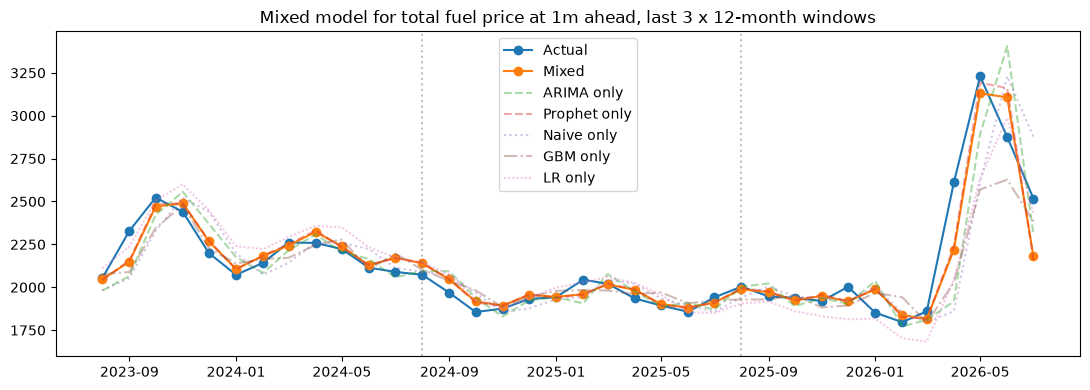

In [127]:
results = run_mixed_model(deisel_df, features_1M_diesel, features_1M_lr, ARIMA_WEIGHT=0, NAIVE_WEIGHT=0, GBM_WEIGHT=0.1, LR_WEIGHT=0)

### Petrol

/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
11:49:39 - cmdstanpy - INFO - Chain [1] start processing
11:49:39 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
11:49:39 - cmdstanpy - INFO - Chain [1] start processing
11:49:39 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  wa

Mixed Model — ARIMA(w=0) + Prophet(w=1.00) + Naive(w=0) + GBM(w=0) + LR(w=0) | horizon=1m | include_2026=True
Averaged over 3 x 12-month windows:
  RMSE: 49.5717
  MAE:  40.1026
  R2:   0.6084
  Directional Accuracy: 75.76%

Per-window breakdown:
 window start_date   end_date      rmse       mae       r2  directional_accuracy
      1 2023-08-01 2024-07-01 62.483098 47.773615 0.613016              0.909091
      2 2024-08-01 2025-07-01 49.295982 39.630855 0.232506              0.727273
      3 2025-08-01 2026-07-01 36.936063 32.903424 0.979618              0.636364


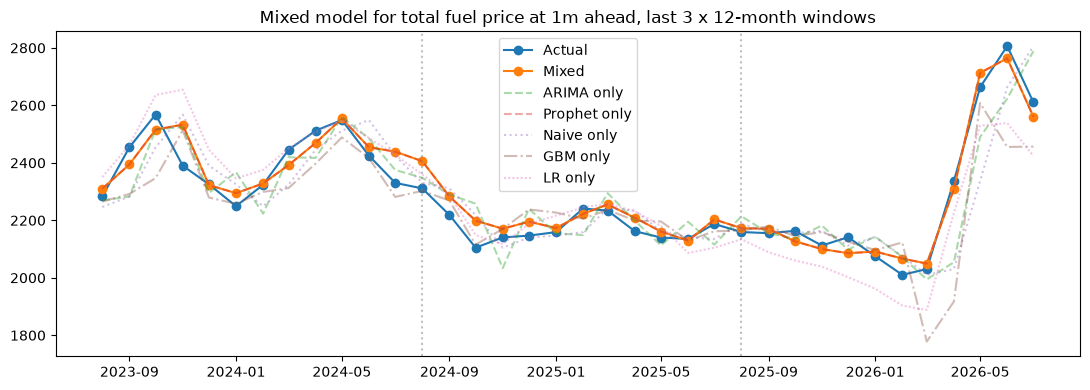

In [128]:
results = run_mixed_model(petrol_df, features_1M_petrol, features_1M_lr, FORECAST_HORIZON=1, ARIMA_WEIGHT=0, NAIVE_WEIGHT=0, GBM_WEIGHT=0, LR_WEIGHT=0)

## 2 Months Ahead

### Diesel

/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
11:49:49 - cmdstanpy - INFO - Chain [1] start processing
11:49:49 - cmdstanpy - INFO - Chain [1] done processing
11:49:50 - cmdstanpy - INFO - Chain [1] start processing
11:49:50 - cmdstanpy - INFO - Chain [1] done processing
11:49:50 - cmdstanpy - INFO - Chain [1] start processing
11:49:50 - cmdstanpy - INFO - Chain [1] done processing
11:49:50 - cmdstanpy - INFO - Chain [1] start processing
11:49:50 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed

Mixed Model — ARIMA(w=0) + Prophet(w=1.00) + Naive(w=0) + GBM(w=0) + LR(w=0) | horizon=2m | include_2026=True
Averaged over 3 x 12-month windows:
  RMSE: 175.0228
  MAE:  126.9159
  R2:   -0.1413
  Directional Accuracy: 48.48%

Per-window breakdown:
 window start_date   end_date       rmse        mae        r2  directional_accuracy
      1 2023-08-01 2024-07-01 146.915675 123.030606 -0.083838              0.636364
      2 2024-08-01 2025-07-01  95.284132  82.923012 -0.951741              0.363636
      3 2025-08-01 2026-07-01 282.868637 174.793988  0.611820              0.454545


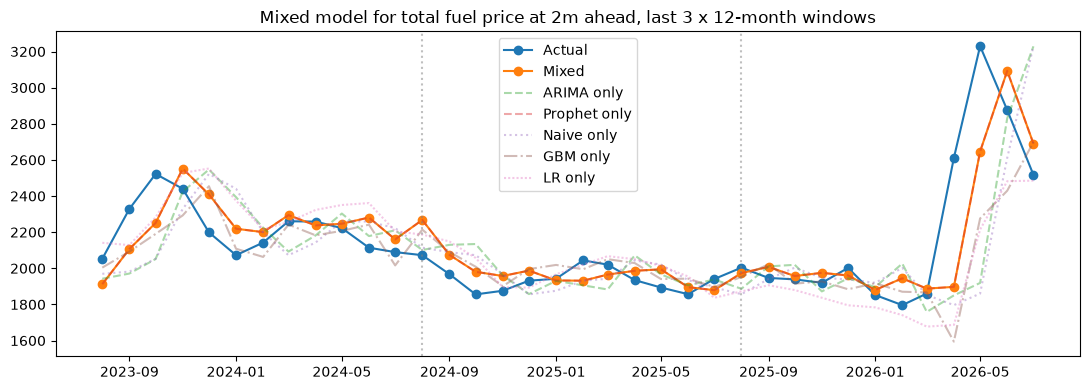

In [129]:
results = run_mixed_model(deisel_df, features_2M_diesel, features_1M_lr, FORECAST_HORIZON=2, ARIMA_WEIGHT=0, NAIVE_WEIGHT=0, GBM_WEIGHT=0, LR_WEIGHT=0)

### Petrol

/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
11:49:59 - cmdstanpy - INFO - Chain [1] start processing
11:49:59 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
11:50:00 - cmdstanpy - INFO - Chain [1] start processing
11:50:00 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  wa

Mixed Model — ARIMA(w=0) + Prophet(w=0.60) + Naive(w=0) + GBM(w=0) + LR(w=0.4) | horizon=2m | include_2026=True
Averaged over 3 x 12-month windows:
  RMSE: 125.6817
  MAE:  95.3920
  R2:   -0.5627
  Directional Accuracy: 57.58%

Per-window breakdown:
 window start_date   end_date       rmse        mae        r2  directional_accuracy
      1 2023-08-01 2024-07-01 131.452846 116.404096 -0.712804              0.636364
      2 2024-08-01 2025-07-01  91.055746  70.494480 -1.618585              0.545455
      3 2025-08-01 2026-07-01 154.536422  99.277284  0.643222              0.545455


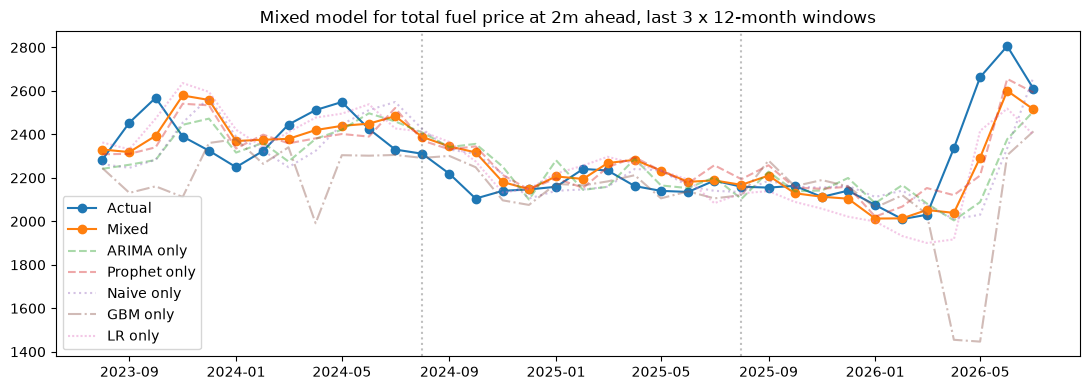

In [130]:
results = run_mixed_model(petrol_df, features_2M_petrol, features_1M_lr, FORECAST_HORIZON=2, ARIMA_WEIGHT=0, NAIVE_WEIGHT=0, GBM_WEIGHT=0, LR_WEIGHT=0.4)

## 3 Months Ahead

### Diesel

/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
11:50:09 - cmdstanpy - INFO - Chain [1] start processing
11:50:09 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
11:50:09 - cmdstanpy - INFO - Chain [1] start processing
11:50:10 - cmdstanpy - INFO - Chain [1] done processing
11:50:10 - cmdstanpy - INFO - Chain [1] start processing
11:50:10 - cmdstanpy - INFO - Chain [1] done processing
11:50:10 - cmdstanpy - INFO - Chain [1] start processing
11:50:10 - cmdstanpy - INFO - Chain [1] done proce

Mixed Model — ARIMA(w=0) + Prophet(w=0.70) + Naive(w=0) + GBM(w=0.3) + LR(w=0) | horizon=3m | include_2026=True
Averaged over 3 x 12-month windows:
  RMSE: 276.0233
  MAE:  182.6981
  R2:   -1.1000
  Directional Accuracy: 54.55%

Per-window breakdown:
 window start_date   end_date       rmse        mae        r2  directional_accuracy
      1 2023-08-01 2024-07-01 210.319146 150.630815 -1.221191              0.636364
      2 2024-08-01 2025-07-01 115.214249 104.900076 -1.853602              0.545455
      3 2025-08-01 2026-07-01 502.536506 292.563538 -0.225178              0.454545


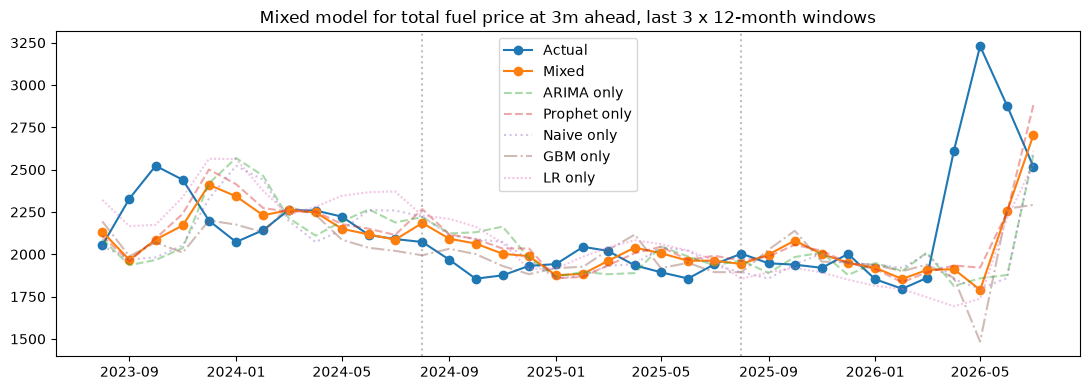

In [131]:
results = run_mixed_model(deisel_df, features_3M_diesel, features_1M_lr, FORECAST_HORIZON=3, ARIMA_WEIGHT=0, NAIVE_WEIGHT=0, GBM_WEIGHT=0.3, LR_WEIGHT=0)

### Petrol

/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
11:57:59 - cmdstanpy - INFO - Chain [1] start processing
11:58:00 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
11:58:00 - cmdstanpy - INFO - Chain [1] start processing
11:58:01 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  wa

Mixed Model — ARIMA(w=0) + Prophet(w=1.00) + Naive(w=0) + GBM(w=0) + LR(w=0) | horizon=3m | include_2026=True
Averaged over 3 x 12-month windows:
  RMSE: 162.0711
  MAE:  117.6864
  R2:   -1.8486
  Directional Accuracy: 51.52%

Per-window breakdown:
 window start_date   end_date       rmse        mae        r2  directional_accuracy
      1 2023-08-01 2024-07-01 131.460816 110.727126 -0.713012              0.454545
      2 2024-08-01 2025-07-01 139.430844 116.758550 -5.140018              0.363636
      3 2025-08-01 2026-07-01 215.321601 125.573503  0.307354              0.727273


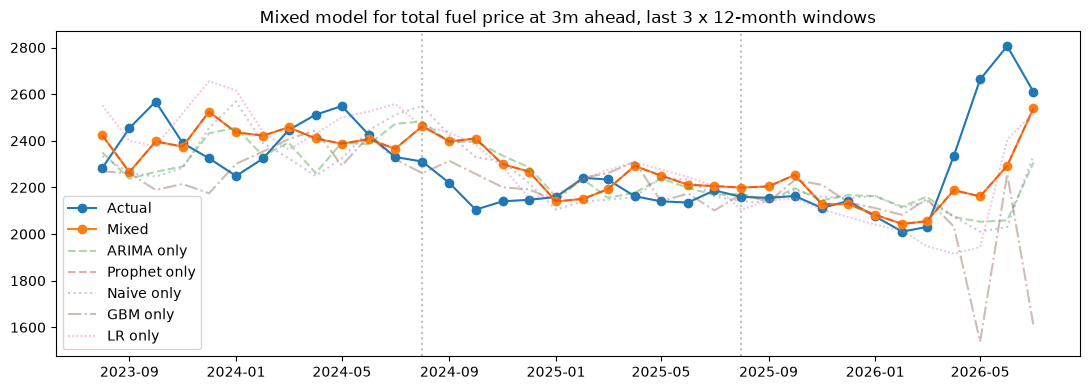

In [132]:
results = run_mixed_model(petrol_df, features_3M_petrol, features_1M_lr, FORECAST_HORIZON=3, ARIMA_WEIGHT=0, NAIVE_WEIGHT=0, GBM_WEIGHT=0, LR_WEIGHT=0)

## 4 Months Ahead

### Diesel

12:03:24 - cmdstanpy - INFO - Chain [1] start processing
12:03:24 - cmdstanpy - INFO - Chain [1] done processing
12:03:24 - cmdstanpy - INFO - Chain [1] start processing
12:03:24 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
12:03:25 - cmdstanpy - INFO - Chain [1] start processing
12:03:25 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
12:03:25 - cmdstanpy - INFO - Chain [1] start processing
12:03:25 - cmdstanpy - INFO - Chain [1] done proce

Mixed Model — ARIMA(w=0) + Prophet(w=0.80) + Naive(w=0) + GBM(w=0.2) + LR(w=0) | horizon=4m | include_2026=True
Averaged over 3 x 12-month windows:
  RMSE: 261.3199
  MAE:  181.9776
  R2:   -1.0493
  Directional Accuracy: 39.39%

Per-window breakdown:
 window start_date   end_date       rmse        mae        r2  directional_accuracy
      1 2023-08-01 2024-07-01 151.082715 122.036590 -0.146193              0.545455
      2 2024-08-01 2025-07-01 132.750085 114.612633 -2.788355              0.363636
      3 2025-08-01 2026-07-01 500.127035 309.283642 -0.213458              0.272727


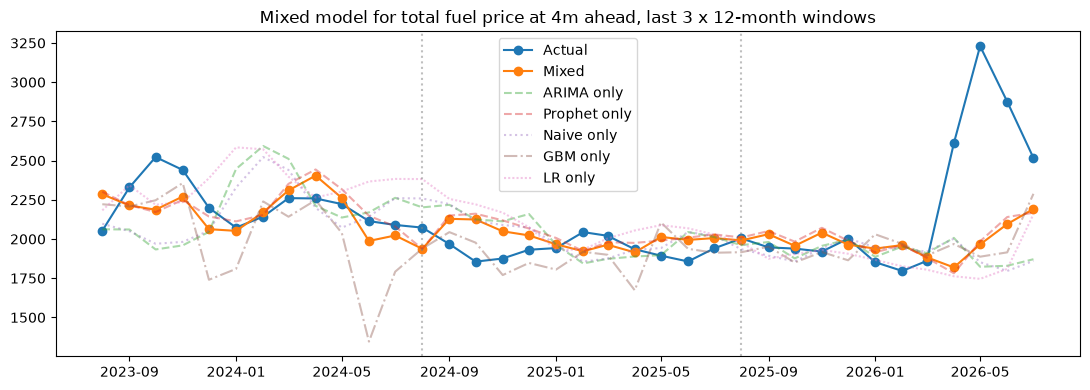

In [133]:
results = run_mixed_model(deisel_df, features_4M_diesel, features_1M_lr, FORECAST_HORIZON=4, ARIMA_WEIGHT=0, NAIVE_WEIGHT=0, GBM_WEIGHT=0.2, LR_WEIGHT=0)

### Petrol

/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
12:03:37 - cmdstanpy - INFO - Chain [1] start processing


12:03:37 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
12:03:37 - cmdstanpy - INFO - Chain [1] start processing
12:03:37 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
12:03:37 - cmdstanpy - INFO - Chain [1] start processing
12:03:37 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood

Mixed Model — ARIMA(w=0) + Prophet(w=0.80) + Naive(w=0) + GBM(w=0.2) + LR(w=0) | horizon=4m | include_2026=True
Averaged over 3 x 12-month windows:
  RMSE: 162.7949
  MAE:  126.8617
  R2:   -1.3962
  Directional Accuracy: 48.48%

Per-window breakdown:
 window start_date   end_date       rmse        mae        r2  directional_accuracy
      1 2023-08-01 2024-07-01  99.958160  87.827708  0.009614              0.727273
      2 2024-08-01 2025-07-01 128.143982 109.473018 -4.186190              0.272727
      3 2025-08-01 2026-07-01 260.282525 183.284313 -0.012106              0.454545


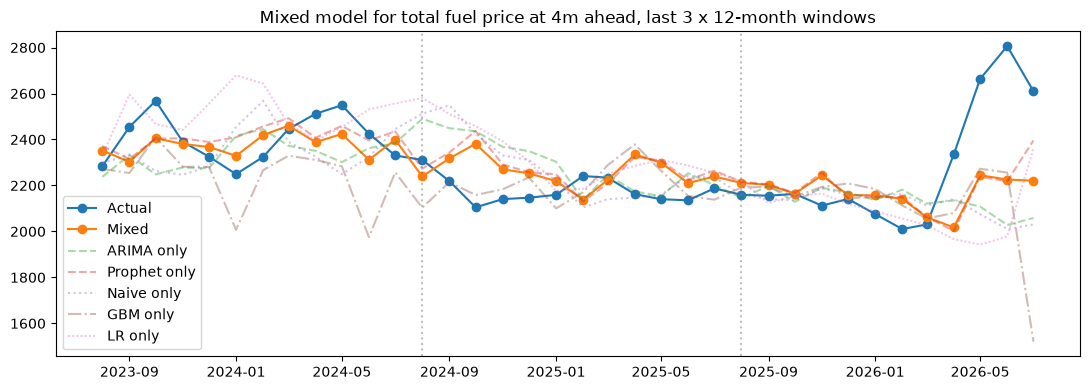

In [134]:
results = run_mixed_model(petrol_df, features_4M_petrol, features_1M_lr, FORECAST_HORIZON=4, ARIMA_WEIGHT=0, NAIVE_WEIGHT=0, GBM_WEIGHT=0.2, LR_WEIGHT=0)

## 5 Months Ahead

### Diesel

/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
12:03:51 - cmdstanpy - INFO - Chain [1] start processing
12:03:51 - cmdstanpy - INFO - Chain [1] done processing
12:03:51 - cmdstanpy - INFO - Chain [1] start processing
12:03:51 - cmdstanpy - INFO - Chain [1] done processing
12:03:51 - cmdstanpy - INFO - Chain [1] start processing
12:03:51 - cmdstanpy - INFO - Chain [1] done processing
12:03:52 - cmdstanpy - INFO - Chain [1] start processing
12:03:52 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed

Mixed Model — ARIMA(w=0) + Prophet(w=0.90) + Naive(w=0) + GBM(w=0.1) + LR(w=0) | horizon=5m | include_2026=True
Averaged over 3 x 12-month windows:
  RMSE: 248.0600
  MAE:  189.6091
  R2:   -1.1300
  Directional Accuracy: 42.42%

Per-window breakdown:
 window start_date   end_date       rmse        mae        r2  directional_accuracy
      1 2023-08-01 2024-07-01 133.189426 111.073521  0.109225              0.636364
      2 2024-08-01 2025-07-01 143.716232 129.147775 -3.440100              0.363636
      3 2025-08-01 2026-07-01 467.274252 328.605923 -0.059272              0.272727


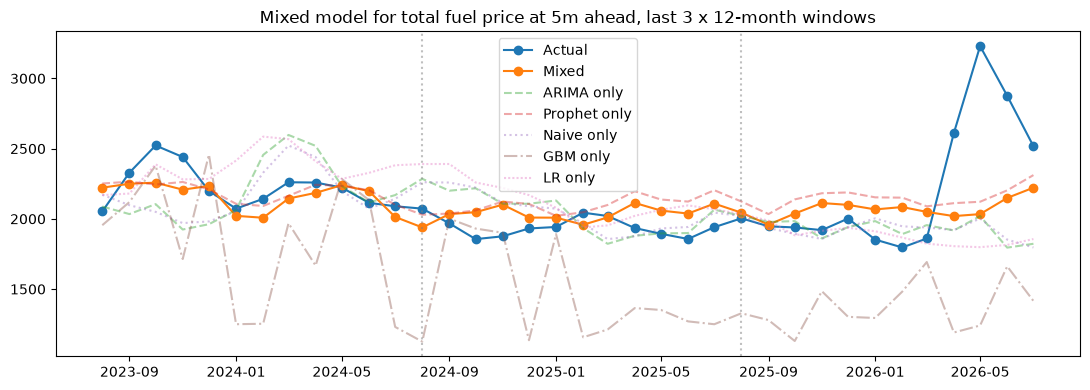

In [135]:
results = run_mixed_model(deisel_df, features_5M_diesel, features_1M_lr, FORECAST_HORIZON=5, ARIMA_WEIGHT=0, NAIVE_WEIGHT=0, GBM_WEIGHT=0.1, LR_WEIGHT=0)

### Petrol

12:04:08 - cmdstanpy - INFO - Chain [1] start processing
12:04:08 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
12:04:08 - cmdstanpy - INFO - Chain [1] start processing
12:04:09 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
12:04:09 - cmdstanpy - INFO - Chain [1] start processing
12:04:09 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/

Mixed Model — ARIMA(w=0) + Prophet(w=0.60) + Naive(w=0) + GBM(w=0.4) + LR(w=0) | horizon=5m | include_2026=True
Averaged over 3 x 12-month windows:
  RMSE: 156.9290
  MAE:  123.2284
  R2:   -0.9524
  Directional Accuracy: 57.58%

Per-window breakdown:
 window start_date   end_date       rmse        mae        r2  directional_accuracy
      1 2023-08-01 2024-07-01 111.499783  98.907602 -0.232298              0.545455
      2 2024-08-01 2025-07-01 107.963413  97.633071 -2.681334              0.545455
      3 2025-08-01 2026-07-01 251.323861 173.144514  0.056366              0.636364


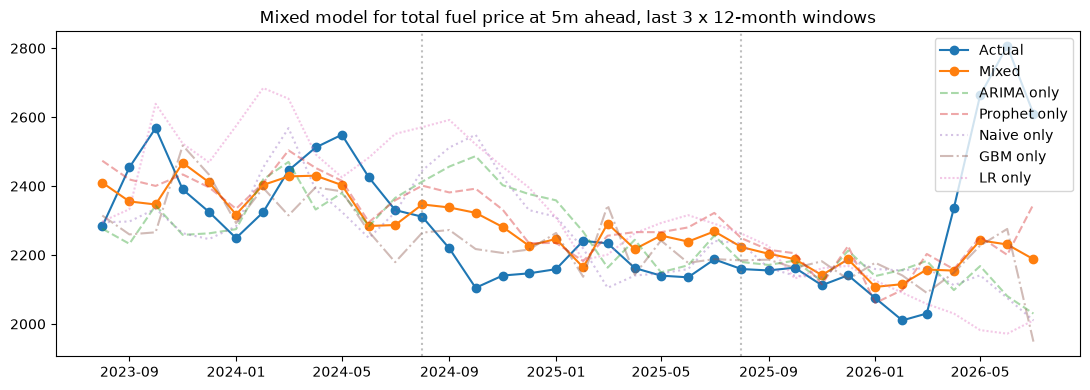

In [136]:
results = run_mixed_model(petrol_df, features_5M_petrol, features_1M_lr, FORECAST_HORIZON=5, ARIMA_WEIGHT=0, NAIVE_WEIGHT=0, GBM_WEIGHT=0.4, LR_WEIGHT=0)

## 6 Months Ahead

### Diesel

12:04:41 - cmdstanpy - INFO - Chain [1] start processing
12:04:41 - cmdstanpy - INFO - Chain [1] done processing
12:04:41 - cmdstanpy - INFO - Chain [1] start processing
12:04:41 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
12:04:41 - cmdstanpy - INFO - Chain [1] start processing
12:04:41 - cmdstanpy - INFO - Chain [1] done processing
12:04:42 - cmdstanpy - INFO - Chain [1] start processing
12:04:42 - cmdstanpy - INFO - Chain [1] done processing
12:04:42 - cmdstanpy - INFO - Chain [1] start processing
12:04:42 - cmdstanpy - INFO - Chain [1] done processing
12:04:42 - cmdstanpy - INFO - Chain [1] start processing
12:04:42 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AM

Mixed Model — ARIMA(w=0.1) + Prophet(w=0.70) + Naive(w=0) + GBM(w=0.2) + LR(w=0) | horizon=6m | include_2026=True
Averaged over 3 x 12-month windows:
  RMSE: 234.3293
  MAE:  172.2338
  R2:   -0.3855
  Directional Accuracy: 63.64%

Per-window breakdown:
 window start_date   end_date       rmse        mae        r2  directional_accuracy
      1 2023-08-01 2024-07-01 128.245413 104.792740  0.174129              0.727273
      2 2024-08-01 2025-07-01 102.250812  95.122940 -1.247577              0.545455
      3 2025-08-01 2026-07-01 472.491714 316.785731 -0.083060              0.636364


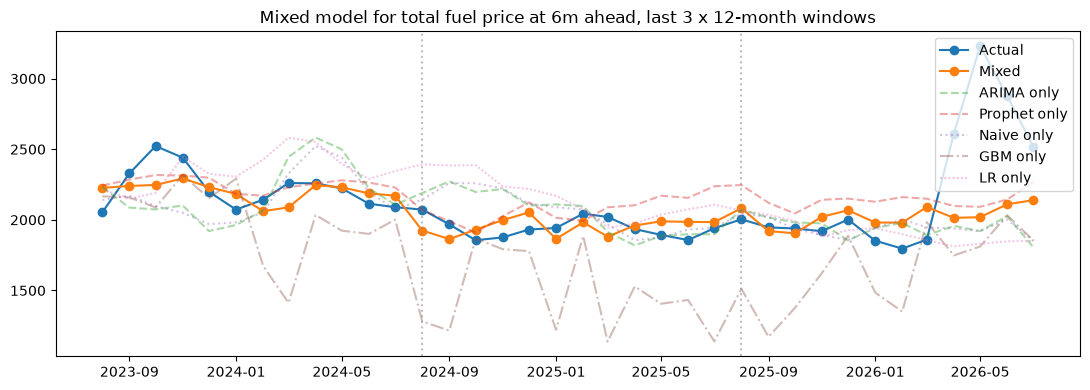

In [137]:
results = run_mixed_model(deisel_df, features_6M_diesel, features_1M_lr, FORECAST_HORIZON=6, ARIMA_WEIGHT=0.1, NAIVE_WEIGHT=0, GBM_WEIGHT=0.2, LR_WEIGHT=0)

### Petrol

/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
12:04:52 - cmdstanpy - INFO - Chain [1] start processing
12:04:52 - cmdstanpy - INFO - Chain [1] done processing
12:04:59 - cmdstanpy - INFO - Chain [1] start processing
12:04:59 - cmdstanpy - INFO - Chain [1] done processing
12:04:59 - cmdstanpy - INFO - Chain [1] start processing
12:04:59 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
12:04:59 - cmdstanpy - INFO - Chain [1] start processing
12:04:59 - cmdstanpy - INFO - Chain [1] done proce

Mixed Model — ARIMA(w=0) + Prophet(w=0.70) + Naive(w=0) + GBM(w=0.3) + LR(w=0) | horizon=6m | include_2026=True
Averaged over 3 x 12-month windows:
  RMSE: 132.4825
  MAE:  102.0721
  R2:   -0.1970
  Directional Accuracy: 54.55%

Per-window breakdown:
 window start_date   end_date       rmse        mae        r2  directional_accuracy
      1 2023-08-01 2024-07-01  75.122121  55.206197  0.440624              0.636364
      2 2024-08-01 2025-07-01  83.004551  77.742328 -1.175984              0.454545
      3 2025-08-01 2026-07-01 239.320871 173.267770  0.144348              0.545455


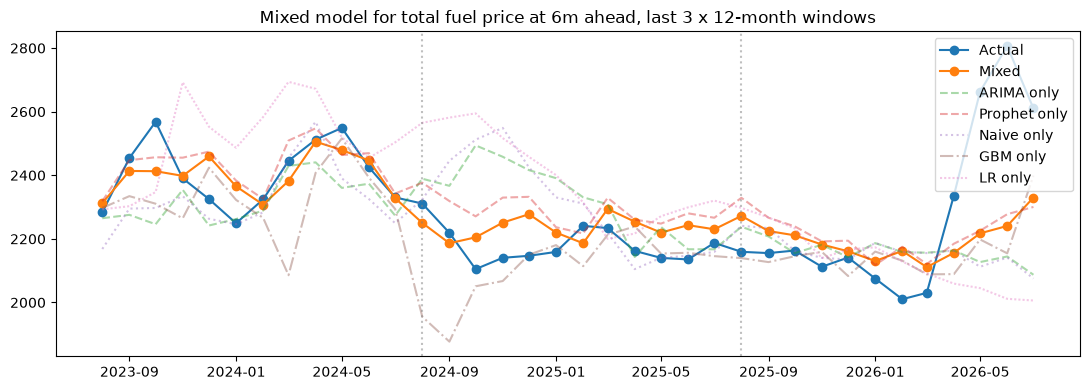

In [138]:
results = run_mixed_model(petrol_df, features_6M_petrol, features_1M_lr, FORECAST_HORIZON=6, ARIMA_WEIGHT=0, NAIVE_WEIGHT=0, GBM_WEIGHT=0.3, LR_WEIGHT=0)

## Weighting formulations based on whole test set

In [82]:
def get_walkforward_predictions(df, feature_cols, lr_feature_cols, target_col="Total_Fuel_Price",
                                 FORECAST_HORIZON=1, TRAIN_RATIO=0.8, ARIMA_ORDER=(2, 1, 5),
                                 gbm_n_estimators=200, gbm_max_depth=3, gbm_learning_rate=0.05,
                                 include_2026=True):
    """
    Runs the walk-forward loop once and returns raw predictions from ARIMA,
    Prophet, Naive, GBM, and Linear Regression — no blending applied yet.
    Reuse this output to search weight combinations cheaply.

    Parameters
    ----------
    feature_cols    : regressor columns used by Prophet and GBM
    lr_feature_cols : regressor columns used by Linear Regression only
    """
    feature_cols = [c for c in feature_cols if c not in ("Date", target_col)]
    lr_feature_cols = [c for c in lr_feature_cols if c not in ("Date", target_col)]

    missing = [c for c in lr_feature_cols if c not in df.columns]
    if missing:
        raise ValueError(f"lr_feature_cols contains columns not found in df: {missing}")

    data = df.copy()
    if not include_2026:
        data = data[data["Date"] < "2026-01-01"]

    # union of both feature sets, so both Prophet/GBM and LR have what they need
    all_needed_cols = list(dict.fromkeys(feature_cols + lr_feature_cols))

    prophet_df = data[["Date", target_col] + all_needed_cols].copy()
    prophet_df = prophet_df.rename(columns={"Date": "ds", target_col: "y_level"})
    prophet_df = prophet_df.sort_values("ds").reset_index(drop=True)

    prophet_df["y"] = prophet_df["y_level"].shift(-FORECAST_HORIZON)
    prophet_df = prophet_df.dropna(subset=["y"] + all_needed_cols).reset_index(drop=True)

    n_total = len(prophet_df)
    split_idx = int(round(n_total * TRAIN_RATIO) - FORECAST_HORIZON)
    if split_idx >= n_total:
        raise ValueError("Test set is empty — check TRAIN_RATIO and data length.")

    dates, y_true_list = [], []
    arima_pred_list, prophet_pred_list, naive_pred_list = [], [], []
    gbm_pred_list, lr_pred_list = [], []

    for i in range(split_idx, n_total):
        train_fold = prophet_df.iloc[:i]           # (features, shifted target) pairs — Prophet/GBM/LR
        level_fold = prophet_df.iloc[:i + 1]        # raw price series through row i's own actual
        test_row = prophet_df.iloc[[i]]

        target_date = test_row["ds"].values[0] + pd.DateOffset(months=FORECAST_HORIZON)

        naive_pred = level_fold["y_level"].iloc[-1]

        arima_model = ARIMA(level_fold["y_level"], order=ARIMA_ORDER)
        arima_fitted = arima_model.fit()
        arima_pred = arima_fitted.forecast(steps=FORECAST_HORIZON).iloc[-1]

        prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
        for col in feature_cols:
            prophet_model.add_regressor(col)
        prophet_model.fit(train_fold[["ds", "y"] + feature_cols])
        prophet_pred = prophet_model.predict(test_row[["ds"] + feature_cols])["yhat"].values[0]

        gbm_model = GradientBoostingRegressor(
            n_estimators=gbm_n_estimators, max_depth=gbm_max_depth,
            learning_rate=gbm_learning_rate, subsample=0.8, random_state=42
        )
        gbm_model.fit(train_fold[feature_cols], train_fold["y"])
        gbm_pred = gbm_model.predict(test_row[feature_cols])[0]

        lr_model = LinearRegression()
        lr_model.fit(train_fold[lr_feature_cols], train_fold["y"])
        lr_pred = lr_model.predict(test_row[lr_feature_cols])[0]

        dates.append(target_date)
        y_true_list.append(test_row["y"].values[0])
        arima_pred_list.append(arima_pred)
        prophet_pred_list.append(prophet_pred)
        naive_pred_list.append(naive_pred)
        gbm_pred_list.append(gbm_pred)
        lr_pred_list.append(lr_pred)

    return pd.DataFrame({
        "ds": dates,
        "y_true": y_true_list,
        "arima_pred": arima_pred_list,
        "prophet_pred": prophet_pred_list,
        "naive_pred": naive_pred_list,
        "gbm_pred": gbm_pred_list,
        "lr_pred": lr_pred_list,
    })

### Weight function over entire test period (3 year forecast)

In [19]:
def find_best_weights(preds_df, step=0.1, metric="rmse"):
    y_true = preds_df["y_true"].values
    arima = preds_df["arima_pred"].values
    prophet = preds_df["prophet_pred"].values
    naive = preds_df["naive_pred"].values
    gbm = preds_df["gbm_pred"].values
    lr = preds_df["lr_pred"].values

    weights = np.round(np.arange(0, 1 + step, step), 4)
    results = []

    for aw in weights:
        for nw in weights:
            for gw in weights:
                for lw in weights:
                    pw = round(1 - aw - nw - gw - lw, 4)
                    if pw < 0:
                        continue

                    mixed = aw * arima + pw * prophet + nw * naive + gw * gbm + lw * lr

                    rmse = root_mean_squared_error(y_true, mixed)
                    mae = mean_absolute_error(y_true, mixed)
                    r2 = r2_score(y_true, mixed)
                    dir_acc = (np.sign(np.diff(y_true)) == np.sign(np.diff(mixed))).mean()

                    results.append({
                        "ARIMA_WEIGHT": aw, "PROPHET_WEIGHT": pw,
                        "NAIVE_WEIGHT": nw, "GBM_WEIGHT": gw, "LR_WEIGHT": lw,
                        "rmse": rmse, "mae": mae, "r2": r2, "directional_accuracy": dir_acc,
                    })

    results_df = pd.DataFrame(results)
    best = (results_df.sort_values("rmse").iloc[0] if metric == "rmse"
            else results_df.sort_values("directional_accuracy", ascending=False).iloc[0])

    return best, results_df

## Weightings based on a rolling one year window

In [29]:
def find_best_weights_yearly(preds_df, n_eval_windows=3, eval_window_size=12,
                              step=0.1, metric="rmse"):
    """
    Grid search over (ARIMA, NAIVE, GBM, LR) weights — Prophet weight is the
    remainder — choosing the blend that minimizes (or maximizes, for
    directional accuracy) the AVERAGE metric across `n_eval_windows`
    non-overlapping `eval_window_size`-month windows, most recent first.

    Operates on already-computed predictions (from get_walkforward_predictions),
    so the weight search itself is cheap — no model refitting here.
    """
    eval_df = preds_df.sort_values("ds").reset_index(drop=True)
    needed_len = n_eval_windows * eval_window_size

    if len(eval_df) < needed_len:
        raise ValueError(
            f"Only {len(eval_df)} predictions available, need at least "
            f"{needed_len} for {n_eval_windows} windows of {eval_window_size} months."
        )

    eval_df = eval_df.iloc[-needed_len:].reset_index(drop=True)

    # split into windows once, upfront — reused across every weight combination
    windows = []
    for w in range(n_eval_windows):
        start = w * eval_window_size
        end = start + eval_window_size
        windows.append(eval_df.iloc[start:end])

    weights = np.round(np.arange(0, 1 + step, step), 4)
    results = []

    for aw in weights:
        for nw in weights:
            for gw in weights:
                for lw in weights:
                    pw = round(1 - aw - nw - gw - lw, 4)
                    if pw < 0:
                        continue

                    window_rmses, window_maes, window_r2s, window_dir_accs = [], [], [], []

                    for block in windows:
                        y_true = block["y_true"].values
                        mixed = (
                            aw * block["arima_pred"].values +
                            pw * block["prophet_pred"].values +
                            nw * block["naive_pred"].values +
                            gw * block["gbm_pred"].values +
                            lw * block["lr_pred"].values
                        )

                        window_rmses.append(root_mean_squared_error(y_true, mixed))
                        window_maes.append(mean_absolute_error(y_true, mixed))
                        window_r2s.append(r2_score(y_true, mixed) if len(y_true) > 1 else np.nan)
                        window_dir_accs.append(
                            (np.sign(np.diff(y_true)) == np.sign(np.diff(mixed))).mean()
                            if len(y_true) > 1 else np.nan
                        )

                    results.append({
                        "ARIMA_WEIGHT": aw, "PROPHET_WEIGHT": pw,
                        "NAIVE_WEIGHT": nw, "GBM_WEIGHT": gw, "LR_WEIGHT": lw,
                        "mean_rmse": np.mean(window_rmses),
                        "mean_mae": np.mean(window_maes),
                        "mean_r2": np.nanmean(window_r2s),
                        "mean_directional_accuracy": np.nanmean(window_dir_accs),
                        "rmse_per_window": window_rmses,
                    })

    results_df = pd.DataFrame(results)

    if metric == "rmse":
        best = results_df.sort_values("mean_rmse").iloc[0]
    elif metric == "directional_accuracy":
        best = results_df.sort_values("mean_directional_accuracy", ascending=False).iloc[0]
    else:
        raise ValueError("metric must be 'rmse' or 'directional_accuracy'")

    return best, results_df

In [101]:
preds_df = get_walkforward_predictions(
    deisel_df, features_6M_diesel, features_1M_lr,
    FORECAST_HORIZON=6, TRAIN_RATIO=0.8
)

best_weights, weight_grid = find_best_weights_yearly(
    preds_df, n_eval_windows=3, eval_window_size=12, step=0.1, metric="rmse"
)
print(best_weights[["ARIMA_WEIGHT", "PROPHET_WEIGHT", "NAIVE_WEIGHT", "GBM_WEIGHT", "LR_WEIGHT", "mean_rmse"]])

11:36:19 - cmdstanpy - INFO - Chain [1] start processing
11:36:19 - cmdstanpy - INFO - Chain [1] done processing
11:36:19 - cmdstanpy - INFO - Chain [1] start processing
11:36:19 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AMX/fools-optimum/venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
11:36:20 - cmdstanpy - INFO - Chain [1] start processing
11:36:20 - cmdstanpy - INFO - Chain [1] done processing
11:36:20 - cmdstanpy - INFO - Chain [1] start processing
11:36:20 - cmdstanpy - INFO - Chain [1] done processing
11:36:20 - cmdstanpy - INFO - Chain [1] start processing
11:36:20 - cmdstanpy - INFO - Chain [1] done processing
11:36:20 - cmdstanpy - INFO - Chain [1] start processing
11:36:20 - cmdstanpy - INFO - Chain [1] done processing
/Users/hoyle/Documents/Uni/4th_Year/MOR441-AM

ARIMA_WEIGHT             0.1
PROPHET_WEIGHT           0.7
NAIVE_WEIGHT             0.0
GBM_WEIGHT               0.2
LR_WEIGHT                0.0
mean_rmse         234.329313
Name: 305, dtype: object


In [122]:
def run_mixed_model(df, feature_cols, target_col="Total_Fuel_Price",
                     FORECAST_HORIZON=1, TRAIN_RATIO=0.8, ARIMA_ORDER=(2, 1, 5),
                     ARIMA_WEIGHT=0.4, NAIVE_WEIGHT=0.2,
                     include_2026=True, plot=True):
    """
    Fits and evaluates a blended ARIMA + Prophet + Naive model using
    rolling-origin (walk-forward) validation — same single-step methodology
    as run_prophet_model.

    At each step:
    - ARIMA forecasts FORECAST_HORIZON steps ahead from the raw price series.
    - Prophet predicts using regressors held at the current row.
    - Naive forecasts the last known observed price, unchanged (persistence
      model) — the standard baseline any real model should beat.

    Blend weights: ARIMA_WEIGHT + NAIVE_WEIGHT + PROPHET_WEIGHT = 1,
    where PROPHET_WEIGHT is derived automatically.

    Parameters
    ----------
    df            : master dataframe (e.g. master_diesel_df)
    feature_cols  : list of selected regressor column names (used by Prophet only)
    target_col    : target price column
    ARIMA_WEIGHT  : blend weight for ARIMA
    NAIVE_WEIGHT  : blend weight for the naive (persistence) forecast
    include_2026  : if False, drops all rows from 2026 onward before modelling
    plot          : if True, shows an actual vs predicted plot for the test set

    Returns
    -------
    dict with rmse, mae, r2, per-step predictions, and the final fitted models
    """
    if ARIMA_WEIGHT + NAIVE_WEIGHT > 1:
        raise ValueError("ARIMA_WEIGHT + NAIVE_WEIGHT must not exceed 1 "
                          "(remainder is assigned to Prophet).")
    PROPHET_WEIGHT = 1 - ARIMA_WEIGHT - NAIVE_WEIGHT

    feature_cols = [c for c in feature_cols if c not in ("Date", target_col)]

    data = df.copy()
    if not include_2026:
        data = data[data["Date"] < "2026-01-01"]

    prophet_df = data[["Date", target_col] + feature_cols].copy()
    prophet_df = prophet_df.rename(columns={"Date": "ds", target_col: "y_level"})
    prophet_df = prophet_df.sort_values("ds").reset_index(drop=True)

    # Shifted target for horizon-ahead prediction (Prophet + evaluation target)
    # y_level (raw, unshifted) kept separately — ARIMA and the naive model both
    # need the actual price series, not the shifted version.
    prophet_df["y"] = prophet_df["y_level"].shift(-FORECAST_HORIZON)
    prophet_df = prophet_df.dropna(subset=["y"] + feature_cols).reset_index(drop=True)

    n_total = len(prophet_df)
    split_idx = int(round(n_total * TRAIN_RATIO))

    if split_idx >= n_total:
        raise ValueError("Test set is empty — check TRAIN_RATIO and data length.")

    dates, y_true_list = [], []
    mixed_pred_list, arima_pred_list, prophet_pred_list, naive_pred_list = [], [], [], []

    for i in range(split_idx, n_total):
        train_fold = prophet_df.iloc[:i]          # Prophet's (features, shifted target) training pairs — excludes row i, since row i's target is what we're predicting
        level_fold = prophet_df.iloc[:i + 1]       # raw price series through and INCLUDING row i's own known actual price
        test_row = prophet_df.iloc[[i]]

        target_date = test_row["ds"].values[0] + pd.DateOffset(months=FORECAST_HORIZON)

        # --- Naive: last known ACTUAL price, i.e. row i's own price (Feb), not train_fold's last row (Jan) ---
        naive_pred = level_fold["y_level"].iloc[-1]

        # --- ARIMA: fit through row i's actual price, THEN forecast forward ---
        arima_model = ARIMA(level_fold["y_level"], order=ARIMA_ORDER)
        arima_fitted = arima_model.fit()
        arima_forecast = arima_fitted.forecast(steps=FORECAST_HORIZON)
        arima_pred = arima_forecast.iloc[-1]

        # --- Prophet: unchanged — trained on (features_t, target_{t+H}) pairs up to row i-1,
        # then predicted using row i's own (known) features ---
        prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
        for col in feature_cols:
            prophet_model.add_regressor(col)
        prophet_model.fit(train_fold[["ds", "y"] + feature_cols])

        fc = prophet_model.predict(test_row[["ds"] + feature_cols])
        prophet_pred = fc["yhat"].values[0]

        mixed_pred = (
            ARIMA_WEIGHT * arima_pred +
            PROPHET_WEIGHT * prophet_pred +
            NAIVE_WEIGHT * naive_pred
        )

        dates.append(target_date)
        y_true_list.append(test_row["y"].values[0])
        mixed_pred_list.append(mixed_pred)
        arima_pred_list.append(arima_pred)
        prophet_pred_list.append(prophet_pred)
        naive_pred_list.append(naive_pred)

    y_true = np.array(y_true_list)
    y_pred = np.array(mixed_pred_list)

    results_df = pd.DataFrame({
        "ds": dates,
        "y_true": y_true,
        "y_pred": y_pred,
        "arima_pred": arima_pred_list,
        "prophet_pred": prophet_pred_list,
        "naive_pred": naive_pred_list,
    })

    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # naive-only benchmark metrics, for comparison in the same run
    naive_rmse = root_mean_squared_error(y_true, results_df["naive_pred"])
    naive_mae = mean_absolute_error(y_true, results_df["naive_pred"])

    print(f"Mixed Model — ARIMA(w={ARIMA_WEIGHT}) + Prophet(w={PROPHET_WEIGHT:.2f}) + "
          f"Naive(w={NAIVE_WEIGHT}) | horizon={FORECAST_HORIZON}m | "
          f"include_2026={include_2026} | walk-forward steps={len(results_df)}")
    print(f"RMSE: {rmse:.4f}  |  Naive-only RMSE: {naive_rmse:.4f}")
    print(f"MAE:  {mae:.4f}  |  Naive-only MAE:  {naive_mae:.4f}")
    print(f"R2:   {r2:.4f}")

    if plot:
        fig, ax = plt.subplots(figsize=(11, 4))
        ax.plot(results_df["ds"], results_df["y_true"], label="Actual", marker="o")
        ax.plot(results_df["ds"], results_df["y_pred"], label="Mixed", marker="o")
        ax.plot(results_df["ds"], results_df["arima_pred"], label="ARIMA only", alpha=0.4, linestyle="--")
        ax.plot(results_df["ds"], results_df["prophet_pred"], label="Prophet only", alpha=0.4, linestyle="--")
        ax.plot(results_df["ds"], results_df["naive_pred"], label="Naive only", alpha=0.4, linestyle=":")
        ax.legend()
        ax.set_title(f"Mixed Model — {target_col} rolling {FORECAST_HORIZON}m-ahead "
                     f"(ARIMA={ARIMA_WEIGHT}, Naive={NAIVE_WEIGHT}, include_2026={include_2026})")
        plt.tight_layout()
        plt.show()

    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "naive_rmse": naive_rmse,
        "naive_mae": naive_mae,
        "arima_model": arima_fitted,
        "prophet_model": prophet_model,
        "results_df": results_df,
        "train_df": train_fold,
    }